# Outlier exercise - nonlinear digital-twin regression

This notebook reproduces the dataset and model from *Example 1 - Outlier detection* in the lecture. It fits the same model to:

1. the original dataset;
2. a dataset with the outliers introduced in the slides;

and compares fitted parameters, predictions, residuals and goodness-of-fit metrics.

## Model and weighting

The digital twin has two outputs with common denominator parameters:

$$\hat y_1=\frac{b_1x_1x_2}{1+b_3x_1+b_4x_2}$$
$$\hat y_2=\frac{b_2x_1x_2}{1+b_3x_1+b_4x_2}$$

The lecture reports error variances $\sigma_{y_1}^2=0.348$ and $\sigma_{y_2}^2=0.0023$. We therefore fit the parameters by weighted nonlinear least squares, using standardized residuals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

pd.set_option('display.float_format', '{:,.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# Data from slide 76. Each row is one industrial observation.
observation = np.arange(1, 14)
x1_clean = np.array([20.0, 30.0, 20.0, 30.0, 25.0, 25.0, 25.0, 15.0, 35.0, 55.0, 55.0, 10.6, 16.0])
x2_clean = np.array([20.0, 20.0, 30.0, 30.0, 25.0, 15.0, 35.0, 25.0, 25.0, 32.8, 55.0, 55.0, 55.0])
y1_clean = np.array([3.61, 5.42, 5.00, 7.50, 5.73, 3.80, 7.30, 4.90, 5.90, 9.15, 13.74, 6.00, 8.20])
y2_clean = np.array([0.43, 0.44, 0.64, 0.66, 0.55, 0.33, 0.79, 0.35, 0.71, 0.926, 1.34, 0.70, 0.84])

# Reported output variances (slide 76).
var_y1 = 0.348
var_y2 = 0.0023
std_y1 = np.sqrt(var_y1)
std_y2 = np.sqrt(var_y2)

clean_data = pd.DataFrame({
    'Observation': observation,
    'x1': x1_clean,
    'x2': x2_clean,
    'y1': y1_clean,
    'y2': y2_clean,
})

clean_data

,Observation,x1,x2,y1,y2
0,1,20.0000,20.0000,3.6100,0.4300
1,2,30.0000,20.0000,5.4200,0.4400
2,3,20.0000,30.0000,5.0000,0.6400
3,4,30.0000,30.0000,7.5000,0.6600
4,5,25.0000,25.0000,5.7300,0.5500
5,6,25.0000,15.0000,3.8000,0.3300
6,7,25.0000,35.0000,7.3000,0.7900
7,8,15.0000,25.0000,4.9000,0.3500
8,9,35.0000,25.0000,5.9000,0.7100
9,10,55.0000,32.8000,9.1500,0.9260


## Dataset with introduced outliers

The modifications exactly follow slide 78:

- Observation 1: $y_1$ changes from 3.61 to 6.61.
- Observation 6: $x_2$ changes from 15 to 20.
- Observation 12: $y_2$ changes from 0.70 to 1.70.

In [2]:
x1_outliers = x1_clean.copy()
x2_outliers = x2_clean.copy()
y1_outliers = y1_clean.copy()
y2_outliers = y2_clean.copy()

# Introduced outliers from the lecture.
y1_outliers[0] = 6.61
x2_outliers[5] = 20.0
y2_outliers[11] = 1.70

introduced_outlier = np.zeros(len(observation), dtype=bool)
introduced_outlier[[0, 5, 11]] = True

outlier_data = pd.DataFrame({
    'Observation': observation,
    'x1': x1_outliers,
    'x2': x2_outliers,
    'y1': y1_outliers,
    'y2': y2_outliers,
    'Introduced outlier': introduced_outlier,
})

outlier_data

,Observation,x1,x2,y1,y2,Introduced outlier
0,1,20.0000,20.0000,6.6100,0.4300,True
1,2,30.0000,20.0000,5.4200,0.4400,False
2,3,20.0000,30.0000,5.0000,0.6400,False
3,4,30.0000,30.0000,7.5000,0.6600,False
4,5,25.0000,25.0000,5.7300,0.5500,False
5,6,25.0000,20.0000,3.8000,0.3300,True
6,7,25.0000,35.0000,7.3000,0.7900,False
7,8,15.0000,25.0000,4.9000,0.3500,False
8,9,35.0000,25.0000,5.9000,0.7100,False
9,10,55.0000,32.8000,9.1500,0.9260,False


## Visual comparison of the two datasets

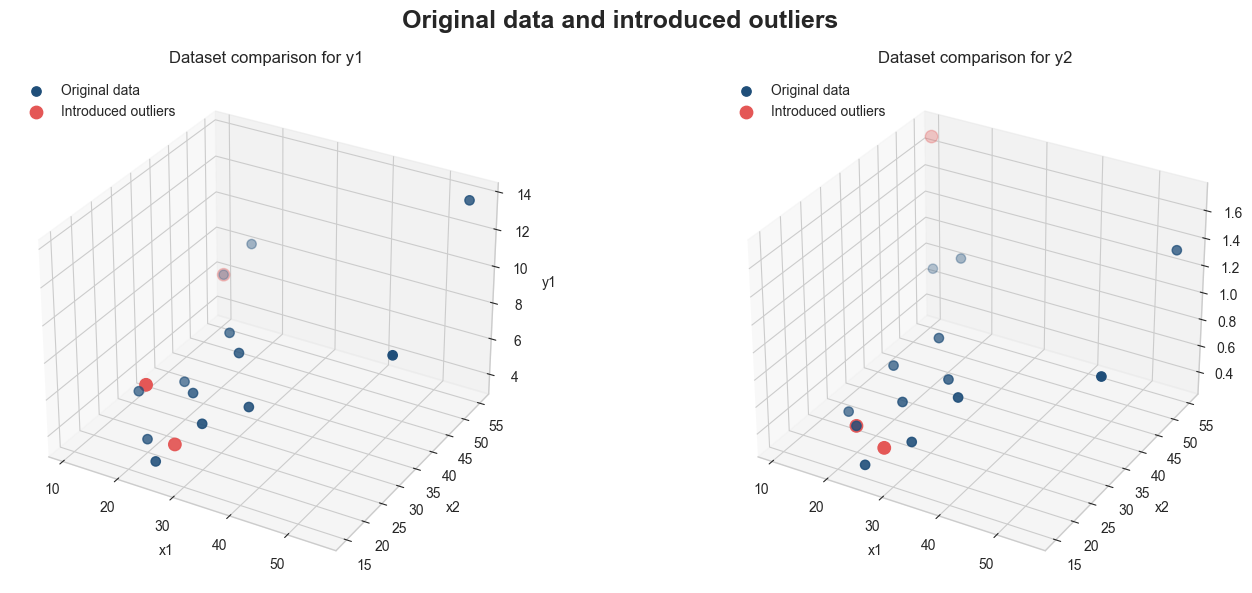

In [11]:
fig = plt.figure(figsize=(15, 6))

# 3D view for y1
ax1 = fig.add_subplot(1, 2, 1, projection="3d")

ax1.scatter(
    x1_clean, x2_clean, y1_clean,
    color="#1F4E79", s=45, label="Original data"
)

ax1.scatter(
    x1_outliers[introduced_outlier],
    x2_outliers[introduced_outlier],
    y1_outliers[introduced_outlier],
    color="#E45756", s=80, label="Introduced outliers"
)

ax1.set_title("Dataset comparison for y1")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("y1")
ax1.legend(loc="upper left")


# 3D view for y2
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

ax2.scatter(
    x1_clean, x2_clean, y2_clean,
    color="#1F4E79", s=45, label="Original data"
)

ax2.scatter(
    x1_outliers[introduced_outlier],
    x2_outliers[introduced_outlier],
    y2_outliers[introduced_outlier],
    color="#E45756", s=80, label="Introduced outliers"
)

ax2.set_title("Dataset comparison for y2")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
ax2.set_zlabel("y2")
ax2.legend(loc="upper left")

fig.suptitle(
    "Original data and introduced outliers",
    fontsize=18,
    weight="bold"
)

fig.tight_layout()
plt.show()

## Fit on the original dataset

The four parameters are estimated by minimizing the sum of squared standardized residuals. The use of the two output variances prevents the larger-scale output $y_1$ from dominating the fit.

In [12]:
initial_guess = np.array([0.04, 0.004, 0.10, 0.02])

fit_clean = least_squares(
    lambda b: np.concatenate([
        (b[0] * x1_clean * x2_clean / (1 + b[2] * x1_clean + b[3] * x2_clean) - y1_clean) / std_y1,
        (b[1] * x1_clean * x2_clean / (1 + b[2] * x1_clean + b[3] * x2_clean) - y2_clean) / std_y2,
    ]),
    x0=initial_guess,
    bounds=(0, np.inf),
)

b_clean = fit_clean.x
denominator_clean = 1 + b_clean[2] * x1_clean + b_clean[3] * x2_clean
y1_hat_clean = b_clean[0] * x1_clean * x2_clean / denominator_clean
y2_hat_clean = b_clean[1] * x1_clean * x2_clean / denominator_clean

parameter_clean = pd.DataFrame({
    'Parameter': ['b1', 'b2', 'b3', 'b4'],
    'Fit on original data': b_clean,
})

parameter_clean

,Parameter,Fit on original data
0,b1,0.0405
1,b2,0.0041
2,b3,0.1164
3,b4,0.0264


## Fit on the dataset with outliers

The same model, weights and initial guess are used. Any difference in the fitted parameters therefore comes only from the altered observations.

In [13]:
fit_outliers = least_squares(
    lambda b: np.concatenate([
        (b[0] * x1_outliers * x2_outliers / (1 + b[2] * x1_outliers + b[3] * x2_outliers) - y1_outliers) / std_y1,
        (b[1] * x1_outliers * x2_outliers / (1 + b[2] * x1_outliers + b[3] * x2_outliers) - y2_outliers) / std_y2,
    ]),
    x0=initial_guess,
    bounds=(0, np.inf),
)

b_outliers = fit_outliers.x
denominator_outliers = 1 + b_outliers[2] * x1_outliers + b_outliers[3] * x2_outliers
y1_hat_outliers = b_outliers[0] * x1_outliers * x2_outliers / denominator_outliers
y2_hat_outliers = b_outliers[1] * x1_outliers * x2_outliers / denominator_outliers

parameter_comparison = pd.DataFrame({
    'Parameter': ['b1', 'b2', 'b3', 'b4'],
    'Original data fit': b_clean,
    'Outlier-contaminated fit': b_outliers,
    'Relative change [%]': 100 * (b_outliers - b_clean) / b_clean,
})

parameter_comparison

,Parameter,Original data fit,Outlier-contaminated fit,Relative change [%]
0,b1,0.0405,0.0586,44.7159
1,b2,0.0041,0.0067,63.5850
2,b3,0.1164,0.2457,111.0082
3,b4,0.0264,0.0000,-100.0000


## Predictions, residuals and metrics

In [7]:
metrics = pd.DataFrame({
    'Metric': ['Weighted sum of squared residuals', 'RMSE y1', 'RMSE y2'],
    'Original data fit': [
        np.sum(fit_clean.fun**2),
        np.sqrt(np.mean((y1_clean - y1_hat_clean)**2)),
        np.sqrt(np.mean((y2_clean - y2_hat_clean)**2)),
    ],
    'Outlier-contaminated fit': [
        np.sum(fit_outliers.fun**2),
        np.sqrt(np.mean((y1_outliers - y1_hat_outliers)**2)),
        np.sqrt(np.mean((y2_outliers - y2_hat_outliers)**2)),
    ],
})

metrics

,Metric,Original data fit,Outlier-contaminated fit
0,Weighted sum of squared residuals,21.8667,356.8420
1,RMSE y1,0.4397,1.6328
2,RMSE y2,0.0509,0.2133


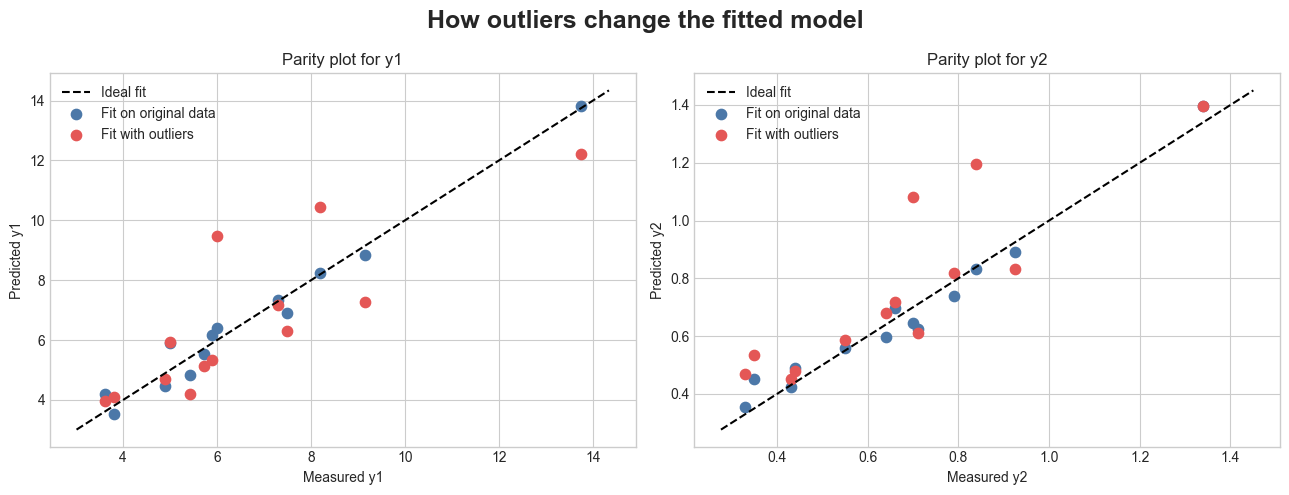

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, measured, predicted_clean, predicted_outlier, label in [
    (axes[0], y1_clean, y1_hat_clean, y1_hat_outliers, 'y1'),
    (axes[1], y2_clean, y2_hat_clean, y2_hat_outliers, 'y2'),
]:
    lower = min(measured.min(), predicted_clean.min(), predicted_outlier.min())
    upper = max(measured.max(), predicted_clean.max(), predicted_outlier.max())
    margin = 0.05 * (upper - lower)
    ax.plot([lower - margin, upper + margin], [lower - margin, upper + margin], '--', color='black', label='Ideal fit')
    ax.scatter(measured, predicted_clean, color='#4C78A8', s=55, label='Fit on original data')
    ax.scatter(measured, predicted_outlier, color='#E45756', s=55, label='Fit with outliers')
    ax.set_xlabel(f'Measured {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'Parity plot for {label}')
    ax.legend()

fig.suptitle('How outliers change the fitted model', fontsize=18, weight='bold')
fig.tight_layout()
plt.show()

## Fitted response surfaces

Each output depends on two inputs, so the fitted model is a three-dimensional response surface. The two panels below show $y_1=f(x_1,x_2)$ and $y_2=f(x_1,x_2)$.

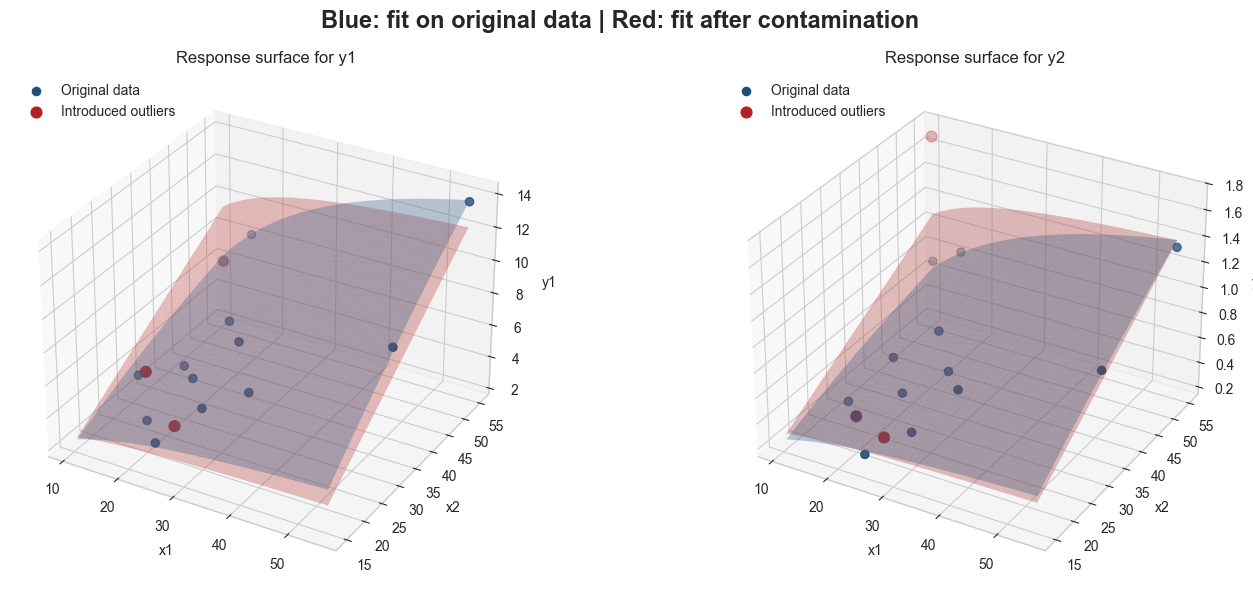

In [10]:
x1_grid = np.linspace(min(x1_clean.min(), x1_outliers.min()), max(x1_clean.max(), x1_outliers.max()), 50)
x2_grid = np.linspace(min(x2_clean.min(), x2_outliers.min()), max(x2_clean.max(), x2_outliers.max()), 50)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

Y1_surface_clean = b_clean[0] * X1_grid * X2_grid / (1 + b_clean[2] * X1_grid + b_clean[3] * X2_grid)
Y2_surface_clean = b_clean[1] * X1_grid * X2_grid / (1 + b_clean[2] * X1_grid + b_clean[3] * X2_grid)
Y1_surface_outliers = b_outliers[0] * X1_grid * X2_grid / (1 + b_outliers[2] * X1_grid + b_outliers[3] * X2_grid)
Y2_surface_outliers = b_outliers[1] * X1_grid * X2_grid / (1 + b_outliers[2] * X1_grid + b_outliers[3] * X2_grid)

fig = plt.figure(figsize=(15, 6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X1_grid, X2_grid, Y1_surface_clean, color='#4C78A8', alpha=0.35, linewidth=0)
ax1.plot_surface(X1_grid, X2_grid, Y1_surface_outliers, color='#E45756', alpha=0.35, linewidth=0)
ax1.scatter(x1_clean, x2_clean, y1_clean, color='#1F4E79', s=35, label='Original data')
ax1.scatter(x1_outliers[introduced_outlier], x2_outliers[introduced_outlier], y1_outliers[introduced_outlier], color='#B22222', s=60, label='Introduced outliers')
ax1.set(title='Response surface for y1', xlabel='x1', ylabel='x2', zlabel='y1')
ax1.legend(loc='upper left')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X1_grid, X2_grid, Y2_surface_clean, color='#4C78A8', alpha=0.35, linewidth=0)
ax2.plot_surface(X1_grid, X2_grid, Y2_surface_outliers, color='#E45756', alpha=0.35, linewidth=0)
ax2.scatter(x1_clean, x2_clean, y2_clean, color='#1F4E79', s=35, label='Original data')
ax2.scatter(x1_outliers[introduced_outlier], x2_outliers[introduced_outlier], y2_outliers[introduced_outlier], color='#B22222', s=60, label='Introduced outliers')
ax2.set(title='Response surface for y2', xlabel='x1', ylabel='x2', zlabel='y2')
ax2.legend(loc='upper left')

fig.suptitle('Blue: fit on original data | Red: fit after contamination', fontsize=17, weight='bold')
fig.tight_layout()
plt.show()

## Iterative outlier detection: clever mean and variance 
The slide-75 algorithm is univariate. Here it is applied separately to the standardized residuals of $y_1$ and $y_2$ after fitting the contaminated dataset. At each iteration, the smallest and largest residual are each compared with the mean and standard deviation computed without that candidate. The candidate with the larger score is removed only when its score is greater than $\delta=2.5$.

In [16]:
delta = 2.5
standardized_residual_y1 = (y1_outliers - y1_hat_outliers) / std_y1
standardized_residual_y2 = (y2_outliers - y2_hat_outliers) / std_y2

detection_rows = []

for response_name, standardized_residuals in [('y1', standardized_residual_y1), ('y2', standardized_residual_y2)]:
    active_observations = list(range(len(observation)))
    iteration = 1

    while len(active_observations) > 2:
        active_residuals = standardized_residuals[active_observations]
        lowest_observation = active_observations[int(np.argmin(active_residuals))]
        highest_observation = active_observations[int(np.argmax(active_residuals))]
        candidate_results = []

        for candidate_observation in [lowest_observation, highest_observation]:
            other_observations = [index for index in active_observations if index != candidate_observation]
            clever_mean = np.mean(standardized_residuals[other_observations])
            clever_std = np.std(standardized_residuals[other_observations], ddof=1)
            clever_score = abs(standardized_residuals[candidate_observation] - clever_mean) / clever_std
            candidate_results.append((clever_score, candidate_observation, clever_mean, clever_std))

        clever_score, candidate_observation, clever_mean, clever_std = max(candidate_results, key=lambda result: result[0])
        detected = clever_score > delta

        detection_rows.append({
            'Response': response_name,
            'Iteration': iteration,
            'Candidate observation': candidate_observation + 1,
            'Candidate standardized residual': standardized_residuals[candidate_observation],
            'Clever mean': clever_mean,
            'Clever standard deviation': clever_std,
            'Clever score': clever_score,
            'Score > delta': detected
        })

        if detected:
            active_observations.remove(candidate_observation)
            iteration += 1
        else:
            break

detection_results = pd.DataFrame(detection_rows)
detection_results.round(3)

,Response,Iteration,Candidate observation,Candidate standardized residual,Clever mean,Clever standard deviation,Clever score,Score > delta
0,y1,1,12,-5.8940,0.9120,2.2330,3.0470,True
1,y1,2,13,-3.8240,1.3430,1.7430,2.9640,True
2,y1,3,1,4.4870,1.0280,1.4730,2.3490,False
3,y2,1,12,12.8770,-1.3300,2.5270,5.6230,True
4,y2,2,13,-7.3870,-0.7790,1.7380,3.8030,True
5,y2,3,8,-3.8700,-0.4700,1.4790,2.2990,False
